# - LibriSpeech Analysis


In [1]:
import os, re, json, time, subprocess, sys
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

try:
    import parselmouth
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth"], check=True)
    import parselmouth
from parselmouth.praat import call

# Percorsi: lascia None per la ricerca automatica in /kaggle/input
LS_ROOT = None     # cartella "train-clean-100"
LA_ROOT = None     # cartella che contiene "ASVspoof2019_LA_cm_protocols"
INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/librispeech_analysis"))
PART_DIR = OUT_DIR / "_parts"
PART_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
N_LS = None                                   # None = tutti i file; un numero = campione casuale (prova rapida)
N_ASV_SPOOF = int(os.environ.get("N_ASV_SPOOF", 2000))   # campione di spoof del train, per contesto
N_DECODE = 100
CHUNK = int(os.environ.get("CHUNK", 1000))
N_WORKERS = os.cpu_count() or 1
EXPECTED_LS_FILES = 28539                     # Attorresi et al., Tab. 1
WHISPER_MAX_S = 30.0

# Praat: pitch come configurazione "standard" del notebook 04
PITCH_FLOOR, PITCH_CEILING = 75.0, 500.0
PITCH_ARGS = (0.0, PITCH_FLOOR, 15, "no", 0.03, 0.45, 0.01, 0.35, 0.14, PITCH_CEILING)
# Praat: parlato/silenzio (Sound: To TextGrid (silences))
SIL_ARGS = (PITCH_FLOOR, 0.0, -25.0, 0.1, 0.1, "silent", "sounding")

print(f"parselmouth {parselmouth.__version__} | Praat {parselmouth.PRAAT_VERSION} | core {N_WORKERS}")

parselmouth 0.4.7 | Praat 6.1.38 | core 4


In [2]:
SKIP = {"flac", "dev-clean", "test-clean", "train-clean-360", "dev-other", "test-other", "train-other-500"}

def find_roots(root):
    ls, la = [], []
    for dirpath, dirnames, _ in os.walk(root):
        if "train-clean-100" in dirnames:
            ls.append(Path(dirpath) / "train-clean-100")
        if "ASVspoof2019_LA_cm_protocols" in dirnames:
            la.append(Path(dirpath))
        dirnames[:] = [d for d in dirnames if d not in SKIP and d != "train-clean-100"
                       and not d.startswith("ASVspoof2019_LA_")]
    return ls, la

if LS_ROOT is None or LA_ROOT is None:
    ls_hits, la_hits = find_roots(INPUT_ROOT)
    print("LibriSpeech:", ls_hits, "\nASVspoof:", la_hits)
    if LS_ROOT is None:
        assert len(ls_hits) == 1, "Imposta LS_ROOT a mano"
        LS_ROOT = ls_hits[0]
    if LA_ROOT is None:
        assert len(la_hits) == 1, "Imposta LA_ROOT a mano"
        LA_ROOT = la_hits[0]
LS_ROOT, LA_ROOT = Path(LS_ROOT), Path(LA_ROOT)
assert LS_ROOT.is_dir() and (LA_ROOT / "ASVspoof2019_LA_cm_protocols").is_dir()
print("LS_ROOT =", LS_ROOT, "\nLA_ROOT =", LA_ROOT)

LibriSpeech: [PosixPath('/kaggle/input/datasets/victorling/librispeech-clean/LibriSpeech/train-clean-100')] 
ASVspoof: [PosixPath('/kaggle/input/datasets/angelopaldino/asvspoof2019-train-dev/LA')]
LS_ROOT = /kaggle/input/datasets/victorling/librispeech-clean/LibriSpeech/train-clean-100 
LA_ROOT = /kaggle/input/datasets/angelopaldino/asvspoof2019-train-dev/LA


In [3]:
rows, n_trans_lines, trans_ids = [], 0, set()
for spk_dir in sorted(p for p in LS_ROOT.iterdir() if p.is_dir()):
    for chap_dir in sorted(p for p in spk_dir.iterdir() if p.is_dir()):
        for f in chap_dir.iterdir():
            if f.suffix == ".flac":
                rows.append({"utt_id": f.stem, "ls_speaker": spk_dir.name, "chapter": chap_dir.name,
                             "path": str(f)})
            elif f.name.endswith(".trans.txt"):
                for line in f.read_text().splitlines():
                    if line.strip():
                        n_trans_lines += 1
                        trans_ids.add(line.split(" ", 1)[0])
ls = pd.DataFrame(rows).sort_values("utt_id").reset_index(drop=True)
ls["speaker"] = "LS_" + ls["ls_speaker"]
ls["group"] = "librispeech"
ls["label"] = "bonafide"

print(f"File .flac: {len(ls)} (attesi {EXPECTED_LS_FILES}) | speaker: {ls['ls_speaker'].nunique()} | capitoli: {ls['chapter'].nunique()}")
print("Nomi file coerenti con speaker-capitolo:",
      bool((ls["utt_id"].str.split("-").str[:2].str.join("-") == ls["ls_speaker"] + "-" + ls["chapter"]).all()))
print(f"Righe nelle trascrizioni: {n_trans_lines} | file senza trascrizione: {len(set(ls['utt_id']) - trans_ids)} "
      f"| trascrizioni senza file: {len(trans_ids - set(ls['utt_id']))}")
print("Duplicati:", ls["utt_id"].duplicated().sum())

# SPEAKERS.TXT (nella cartella che contiene train-clean-100)
spk_file = next((p for p in [LS_ROOT.parent / "SPEAKERS.TXT", LS_ROOT.parent.parent / "SPEAKERS.TXT"] if p.exists()), None)
if spk_file is not None:
    lines = spk_file.read_text(errors="replace").splitlines()
    print("\nPrime righe di SPEAKERS.TXT:"); print("\n".join(lines[:15]))
    recs = []
    for line in lines:
        if line.startswith(";") or "|" not in line:
            continue
        parts = [p.strip() for p in line.split("|")]
        if len(parts) >= 4:
            recs.append({"ls_speaker": parts[0], "sex": parts[1], "subset": parts[2], "minutes": parts[3]})
    spk = pd.DataFrame(recs)
    info = spk[spk["ls_speaker"].isin(ls["ls_speaker"].unique())]
    print("\nSpeaker trovati in SPEAKERS.TXT:", len(info), "su", ls["ls_speaker"].nunique())
    print("Sottoinsieme dichiarato:", info["subset"].value_counts().to_dict())
    print("Sesso:", info["sex"].value_counts().to_dict())
    ls = ls.merge(info[["ls_speaker", "sex"]], on="ls_speaker", how="left")
else:
    print("SPEAKERS.TXT non trovato")

if N_LS is not None:
    ls = ls.sample(n=min(N_LS, len(ls)), random_state=SEED).reset_index(drop=True)
    print(f"\nATTENZIONE: analisi su un campione di {len(ls)} file")

File .flac: 28539 (attesi 28539) | speaker: 251 | capitoli: 585
Nomi file coerenti con speaker-capitolo: True
Righe nelle trascrizioni: 28539 | file senza trascrizione: 0 | trascrizioni senza file: 0
Duplicati: 0

Prime righe di SPEAKERS.TXT:
; Some pipe(|) separated metadata about all LibriVox readers, whose work was used
; in the corpus.
;
; The meaning of the fields in left-to-right order is as follows:
;
; reader_id: the ID of the reader in the LibriVox's database
; gender: 'F' for female, 'M' for male
; subset: the corpus subset to which the reader's audio is assigned
; duration: total number of minutes of speech by the reader, included in the corpus
; name: the name under which the reader is registered in LibriVox
;
;ID  |SEX| SUBSET           |MINUTES| NAME
14   | F | train-clean-360  | 25.03 | Kristin LeMoine
16   | F | train-clean-360  | 25.11 | Alys AtteWater
17   | M | train-clean-360  | 25.04 | Gord Mackenzie

Speaker trovati in SPEAKERS.TXT: 251 su 251
Sottoinsieme dichiar

In [4]:
proto_dir = LA_ROOT / "ASVspoof2019_LA_cm_protocols"
asv = []
for split, pat in [("train", r"cm[._]train[._]trn"), ("dev", r"cm[._]dev[._]trl")]:
    f = [p for p in proto_dir.iterdir() if re.search(pat, p.name)]
    assert len(f) == 1, f
    d = pd.read_csv(f[0], sep=r"\s+", header=None, dtype=str, keep_default_na=False, engine="python",
                    names=["speaker", "utt_id", "unused", "attack", "label"])
    d["path"] = [str(LA_ROOT / f"ASVspoof2019_LA_{split}" / "flac" / f"{u}.flac") for u in d["utt_id"]]
    bona = d[d["label"] == "bonafide"].assign(group=f"asv_bonafide_{split}")
    asv.append(bona)
    if split == "train":
        asv.append(d[d["label"] == "spoof"].sample(n=N_ASV_SPOOF, random_state=SEED).assign(group="asv_spoof_train_campione"))
asv = pd.concat(asv, ignore_index=True)[["utt_id", "speaker", "label", "attack", "path", "group"]]
print(asv["group"].value_counts())

group
asv_bonafide_train          2580
asv_bonafide_dev            2548
asv_spoof_train_campione    2000
Name: count, dtype: int64


In [5]:
def header(path):
    try:
        i = sf.info(path)
        return i.samplerate, i.channels, i.frames / i.samplerate, i.subtype, ""
    except Exception as e:
        return np.nan, np.nan, np.nan, "", repr(e)

allf = pd.concat([ls[["utt_id", "path", "group", "label", "speaker"]], asv[["utt_id", "path", "group", "label", "speaker"]]],
                 ignore_index=True)
with ThreadPoolExecutor(16) as ex:
    h = list(ex.map(header, allf["path"]))
allf[["sr", "channels", "duration_s", "subtype", "read_error"]] = pd.DataFrame(h, index=allf.index)

print("Errori di lettura header:", (allf["read_error"] != "").sum())
print("Frequenze di campionamento:", allf.groupby("group")["sr"].unique().to_dict())
print("Canali:", allf.groupby("group")["channels"].unique().to_dict())
ls_d = allf.loc[allf["group"] == "librispeech", "duration_s"]
print(f"\nLibriSpeech: {ls_d.sum() / 3600:.1f} ore | file oltre {WHISPER_MAX_S:.0f} s: {(ls_d > WHISPER_MAX_S).sum()} "
      f"| oltre 20 s: {(ls_d > 20).sum()} | durata massima {ls_d.max():.2f} s")

samp = allf[allf["group"] == "librispeech"].sample(n=min(N_DECODE, (allf["group"] == "librispeech").sum()), random_state=SEED)
diffs, fails = [], 0
for p in samp["path"]:
    try:
        x, _ = sf.read(p, dtype="float32")
        y = parselmouth.Sound(p).values[0]
        diffs.append(float(np.max(np.abs(x - y))) if len(x) == len(y) else np.inf)
    except Exception:
        fails += 1
print(f"Decodifica LibriSpeech (campione di {len(samp)}): errori {fails} | "
      f"differenza max soundfile vs Parselmouth: {np.max(diffs) if diffs else float('nan')}")

Errori di lettura header: 0
Frequenze di campionamento: {'asv_bonafide_dev': array([16000]), 'asv_bonafide_train': array([16000]), 'asv_spoof_train_campione': array([16000]), 'librispeech': array([16000])}
Canali: {'asv_bonafide_dev': array([1]), 'asv_bonafide_train': array([1]), 'asv_spoof_train_campione': array([1]), 'librispeech': array([1])}

LibriSpeech: 100.6 ore | file oltre 30 s: 0 | oltre 20 s: 1 | durata massima 24.52 s
Decodifica LibriSpeech (campione di 100): errori 0 | differenza max soundfile vs Parselmouth: 0.0


In [6]:
def measure(path):
    out = {"path": path, "m_error": ""}
    try:
        snd = parselmouth.Sound(path)
        dur = snd.duration
        # voce (pitch come notebook 04, configurazione standard)
        pitch = call(snd, "To Pitch (cc)", *PITCH_ARGS)
        f0, t = np.asarray(pitch.selected_array["frequency"]), np.asarray(pitch.xs())
        v = np.where(f0 > 0)[0]
        out["voiced_frac"] = float((f0 > 0).mean()) if len(f0) else np.nan
        out["lead_unvoiced_s"] = float(t[v[0]]) if len(v) else dur
        out["trail_unvoiced_s"] = float(dur - t[v[-1]]) if len(v) else dur
        out["f0_median"] = float(np.median(f0[v])) if len(v) else np.nan
        out["f0_std"] = float(np.std(f0[v])) if len(v) > 1 else np.nan
        inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR).values[0]
        out["intensity_mean"] = float(np.mean(inten[np.isfinite(inten)])) if np.isfinite(inten).any() else np.nan
        # parlato/silenzio
        tg = call(snd, "To TextGrid (silences)", *SIL_ARGS)
        n = call(tg, "Get number of intervals", 1)
        iv = [(call(tg, "Get label of interval", 1, i), call(tg, "Get start time of interval", 1, i),
               call(tg, "Get end time of interval", 1, i)) for i in range(1, n + 1)]
        sounding = [(a, b) for lab, a, b in iv if lab == "sounding"]
        out["speech_s"] = float(sum(b - a for a, b in sounding))
        out["speech_frac"] = out["speech_s"] / dur if dur > 0 else np.nan
        out["lead_silence_s"] = float(sounding[0][0]) if sounding else dur
        out["trail_silence_s"] = float(dur - sounding[-1][1]) if sounding else dur
        out["n_internal_pauses"] = max(len(sounding) - 1, 0)
    except Exception as e:
        out["m_error"] = repr(e)
    return out

todo_paths = allf["path"].tolist()
done = set()
for f in PART_DIR.glob("part_*.csv"):
    done |= set(pd.read_csv(f, usecols=["path"])["path"])
todo_paths = [p for p in todo_paths if p not in done]
print(f"Già misurati: {len(done)} | da misurare: {len(todo_paths)}")
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    for k in range(0, len(todo_paths), CHUNK):
        chunk = todo_paths[k:k + CHUNK]
        res = list(ex.map(measure, chunk, chunksize=8))
        pd.DataFrame(res).to_csv(PART_DIR / f"part_{len(done) + k:07d}.csv", index=False)
        el = time.perf_counter() - t0
        print(f"  {k + len(chunk)}/{len(todo_paths)}  ({el / 60:.1f} min, stima residua "
              f"{el / (k + len(chunk)) * (len(todo_paths) - k - len(chunk)) / 60:.0f} min)")
meas = pd.concat([pd.read_csv(f) for f in sorted(PART_DIR.glob("part_*.csv"))], ignore_index=True).drop_duplicates("path")
data = allf.merge(meas, on="path", how="left", validate="one_to_one")
print("Errori di misura:", (data["m_error"].fillna("") != "").sum())

Già misurati: 0 | da misurare: 35667
  1000/35667  (2.3 min, stima residua 79 min)
  2000/35667  (4.6 min, stima residua 78 min)
  3000/35667  (6.9 min, stima residua 75 min)
  4000/35667  (9.4 min, stima residua 74 min)
  5000/35667  (11.8 min, stima residua 72 min)
  6000/35667  (14.1 min, stima residua 70 min)
  7000/35667  (16.6 min, stima residua 68 min)
  8000/35667  (19.1 min, stima residua 66 min)
  9000/35667  (21.5 min, stima residua 64 min)
  10000/35667  (23.9 min, stima residua 61 min)
  11000/35667  (26.3 min, stima residua 59 min)
  12000/35667  (28.7 min, stima residua 57 min)
  13000/35667  (31.1 min, stima residua 54 min)
  14000/35667  (33.5 min, stima residua 52 min)
  15000/35667  (35.9 min, stima residua 49 min)
  16000/35667  (38.3 min, stima residua 47 min)
  17000/35667  (40.7 min, stima residua 45 min)
  18000/35667  (42.9 min, stima residua 42 min)
  19000/35667  (45.4 min, stima residua 40 min)
  20000/35667  (47.8 min, stima residua 37 min)
  21000/35667  (

In [7]:
MEASURES = ["duration_s", "lead_silence_s", "trail_silence_s", "speech_frac", "n_internal_pauses",
            "lead_unvoiced_s", "trail_unvoiced_s", "voiced_frac", "f0_median", "f0_std", "intensity_mean"]
ORDER = ["librispeech", "asv_bonafide_train", "asv_bonafide_dev", "asv_spoof_train_campione"]
ok = data[data["m_error"].fillna("") == ""]
pct = [.05, .25, .5, .75, .95]
tables = {}
for m in MEASURES:
    t = ok.groupby("group")[m].describe(percentiles=pct).reindex(ORDER)[["count", "mean", "5%", "25%", "50%", "75%", "95%", "max"]]
    tables[m] = t
    print(f"\n=== {m}"); display(t.round(3))

medians = ok.groupby("group")[MEASURES].median().reindex(ORDER).T
display(medians.round(3))

# Stime utili per decidere come trattare la durata (solo aritmetica sui valori misurati)
ls_ok = ok[ok["group"] == "librispeech"]
bona_med = ok.loc[ok["group"] == "asv_bonafide_train", "duration_s"].median()
print(f"\nLibriSpeech: {ls_ok['duration_s'].sum() / 3600:.1f} ore totali, {ls_ok['speech_s'].sum() / 3600:.1f} ore di parlato")
print(f"Mediana durata bona fide ASVspoof (train): {bona_med:.2f} s")
print(f"Stima segmenti LibriSpeech di durata ~mediana ASVspoof: {ls_ok['duration_s'].sum() / bona_med:,.0f} "
      f"(sul solo parlato: {ls_ok['speech_s'].sum() / bona_med:,.0f})")


=== duration_s


,count,mean,5%,25%,50%,75%,95%,max
group,,,,,,,,
librispeech,28539.0,12.689,4.245,11.620,13.995,15.165,16.085,24.525
asv_bonafide_train,2580.0,3.389,2.047,2.688,3.240,3.922,5.161,11.129
asv_bonafide_dev,2548.0,3.508,2.000,2.727,3.387,4.137,5.419,11.389
asv_spoof_train_campione,2000.0,3.394,1.563,2.401,3.197,4.136,5.833,11.838



=== lead_silence_s


,count,mean,5%,25%,50%,75%,95%,max
group,,,,,,,,
librispeech,28539.0,0.353,0.163,0.236,0.323,0.462,0.591,2.308
asv_bonafide_train,2580.0,1.075,0.673,0.837,1.004,1.241,1.739,2.839
asv_bonafide_dev,2548.0,1.185,0.706,0.912,1.090,1.347,1.993,5.176
asv_spoof_train_campione,2000.0,0.697,0.000,0.206,0.558,1.133,1.624,3.456



=== trail_silence_s


...

,count,mean,5%,25%,50%,75%,95%,max
group,,,,,,,,
librispeech,28539.0,45.531,20.579,32.643,42.987,54.638,78.792,195.929
asv_bonafide_train,2580.0,33.984,9.446,18.246,32.591,46.273,65.342,136.791
asv_bonafide_dev,2548.0,36.012,11.963,20.604,33.628,48.660,67.620,125.548
asv_spoof_train_campione,2000.0,25.065,8.562,14.371,21.293,32.104,55.029,113.347



=== intensity_mean


,count,mean,5%,25%,50%,75%,95%,max
group,,,,,,,,
librispeech,28539.0,58.524,51.368,56.213,59.047,61.583,64.971,75.417
asv_bonafide_train,2580.0,56.810,48.525,53.353,56.789,60.244,65.078,75.466
asv_bonafide_dev,2548.0,55.787,46.979,52.687,56.195,59.308,63.161,70.746
asv_spoof_train_campione,2000.0,59.748,47.138,54.895,60.135,64.805,70.769,78.082


group,librispeech,asv_bonafide_train,asv_bonafide_dev,asv_spoof_train_campione
duration_s,13.995,3.240,3.387,3.197
lead_silence_s,0.323,1.004,1.090,0.558
trail_silence_s,0.322,0.397,0.420,0.416
speech_frac,0.697,0.488,0.463,0.592
n_internal_pauses,9.000,0.000,0.000,1.000
lead_unvoiced_s,0.328,1.004,1.097,0.466
trail_unvoiced_s,0.345,0.424,0.450,0.431
voiced_frac,0.527,0.359,0.337,0.452
f0_median,157.769,181.501,193.388,183.003
f0_std,42.987,32.591,33.628,21.293



LibriSpeech: 100.6 ore totali, 68.8 ore di parlato
Mediana durata bona fide ASVspoof (train): 3.24 s
Stima segmenti LibriSpeech di durata ~mediana ASVspoof: 111,767 (sul solo parlato: 76,457)


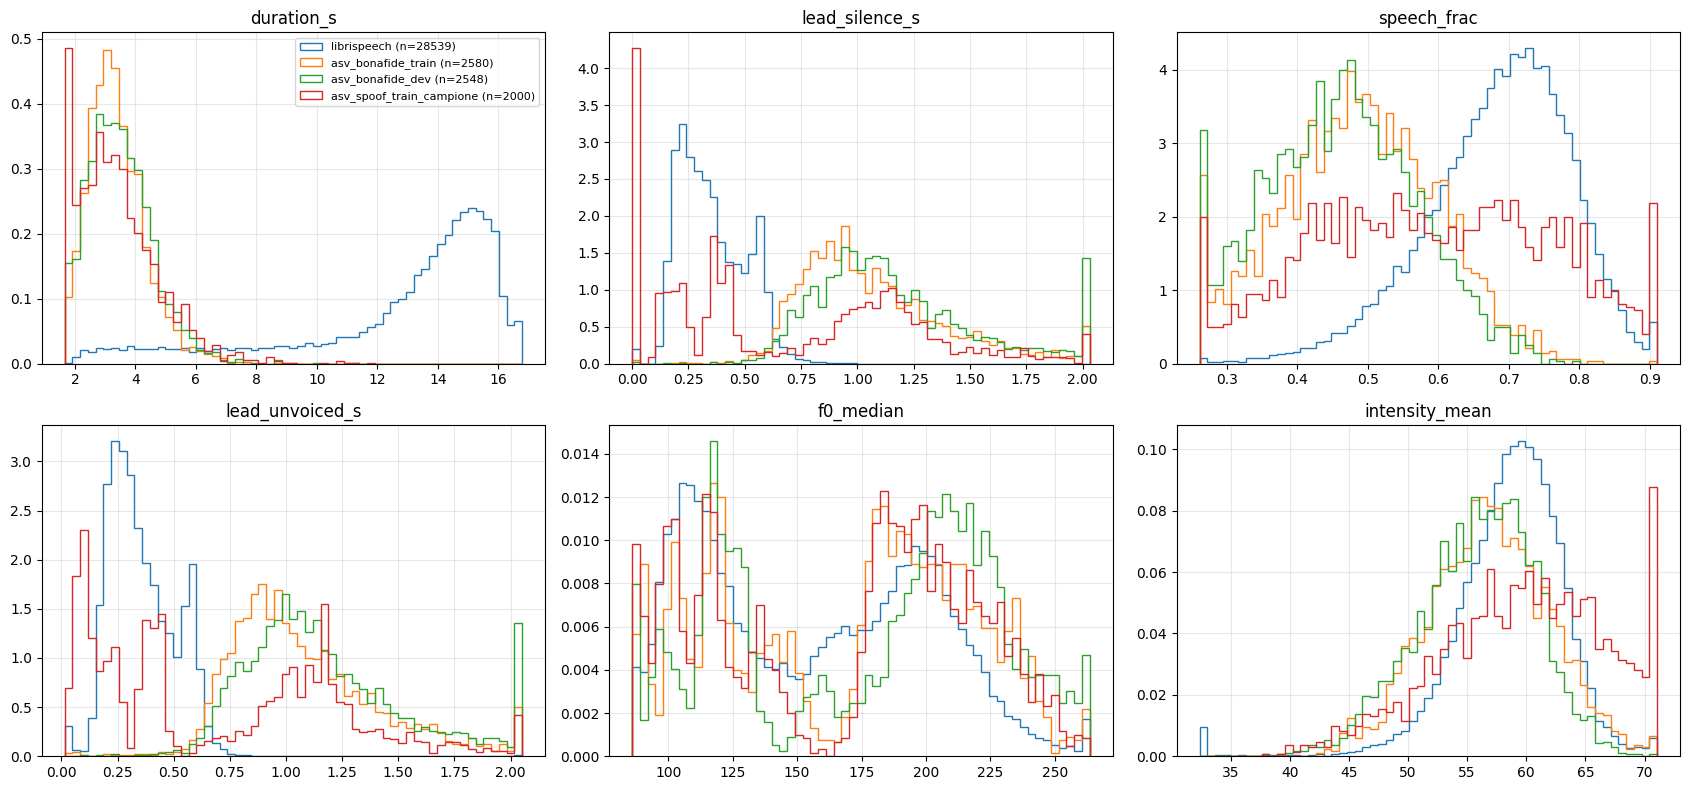

In [8]:
PLOTS = ["duration_s", "lead_silence_s", "speech_frac", "lead_unvoiced_s", "f0_median", "intensity_mean"]
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, m in zip(axes.ravel(), PLOTS):
    vals = ok[m].dropna()
    lo, hi = np.percentile(vals, [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    for g in ORDER:
        x = ok.loc[ok["group"] == g, m].dropna()
        ax.hist(np.clip(x, lo, hi), bins=bins, density=True, histtype="step", lw=1.5, label=f"{g} (n={len(x)})")
    ax.set_title(m); ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "distributions.png", dpi=120); plt.show()

In [9]:
data.to_csv(OUT_DIR / "measures_all.csv", index=False)
ls_manifest = ls.merge(data[data["group"] == "librispeech"].drop(columns=["group", "label", "speaker"]),
                       on=["utt_id", "path"], how="left")
ls_manifest["relpath"] = [str(Path(p).relative_to(LS_ROOT)) for p in ls_manifest["path"]]
ls_manifest.drop(columns=["path"]).to_csv(OUT_DIR / "librispeech_train_clean_100_manifest.csv", index=False)
medians.to_csv(OUT_DIR / "medians_by_group.csv")
summary = {
    "ls_root": str(LS_ROOT), "n_ls_files": int((data["group"] == "librispeech").sum()),
    "expected_ls_files": EXPECTED_LS_FILES, "n_ls_speakers": int(ls["ls_speaker"].nunique()),
    "ls_hours": float(ls_ok["duration_s"].sum() / 3600), "ls_speech_hours": float(ls_ok["speech_s"].sum() / 3600),
    "ls_files_over_30s": int((ls_ok["duration_s"] > WHISPER_MAX_S).sum()),
    "groups": data["group"].value_counts().to_dict(),
    "medians": medians.round(4).to_dict(),
    "params": {"pitch_cc": list(PITCH_ARGS), "silences": list(SIL_ARGS), "seed": SEED, "n_asv_spoof": N_ASV_SPOOF},
    "praat_version": parselmouth.PRAAT_VERSION, "parselmouth_version": parselmouth.__version__,
}
_ = (OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=str))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir()))

Output: ['_parts', 'distributions.png', 'librispeech_train_clean_100_manifest.csv', 'measures_all.csv', 'medians_by_group.csv', 'summary.json']
